We need to turn $E_i$ itself into an empirical probability without changing the conceptual variable.

Estimate from all observations:

$$\xi_{emp}(t) = P\big(I_i(t)=1 \mid E_i(t)\big)$$

where $I_i$ is independently defined by an extreme-return / volatility criterion:

$$I_i(t) = \mathbf{1}\big(|r_i(t)| > q_i^{90\%}\big).$$

For each time step and each stock you have a pair $(E_i, I_i)$ — for instance $(0.52, 1)$, $(0.1, 0)$ (basically $I_i$ is either 1 or 0).

Let's assume we have $N_{stocks} \times N_{steps}$ observations, out of which 10000 (roughly 10% with $q_i^{90}$) have $I_i = 1$. Then

$$\xi_{emp} = P\big(I=1 \mid 0 < E_i^{bin} < 0.1\big) = \frac{\#\{E_i \text{ in bin } E_i^{bin}\}}{10000} = f(E_i^{bin}).$$

You do that for each binning of $E_i^{bin}$. Make a plot of $P(I=1 \mid E_i^{bin})$ as a function of $E_i^{bin}$.

Then we can compare $\xi_{SIS}$ with $\xi_{emp}$ in the dynamical section instead of $E_i$ (keeping the same pipeline for everything) — but at least we have a valid proxy where we map a stressed asset to a probability, so the plot is legitimate when we compute $x_i^{SIS}(t)$ and $\xi_{emp}(t)$ on the same plot.

# De l'énergie de corrélation à une probabilité de stress

**Le problème.** Le modèle SIS donne $x_i(t)\in[0,1]$ = *probabilité* que l'actif
$i$ soit « infecté ». On aimerait le comparer à un observable réel. Jusqu'ici on
le comparait à l'**énergie de corrélation**
$$E_i(t) = \frac{1}{N-1}\sum_{j\neq i} |\rho_{ij}(t)|,$$
la corrélation absolue moyenne de l'actif au reste du marché. Mais $E_i$ vit sur
$[0,1]$ **sans être une probabilité** : comparer une probabilité ($x_i^{SIS}$) à
une énergie ($E_i$) n'a pas d'unité commune.

**L'idée.** Transformer $E_i$ en une vraie probabilité, sans changer la variable,
en la **calibrant** sur un événement de marché indépendant : un rendement extrême.

Ce notebook déroule l'idée étape par étape, chaque étape avec un graphe.

In [1]:
import sys
sys.path.insert(0, '../code')
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

from data import build_context
import analysis, model, config

ctx = build_context()                          # données + E_i journalier + matrices A (cache)
E   = ctx.E_daily_all                          # (N, jours) énergie de corrélation
R   = analysis.daily_log_returns(ctx.data, ctx.all_days)   # rendements journaliers
I   = analysis.extreme_indicator(R, q=0.90)       # 1 si |rendement| dans le top 10% de l'actif
days = pd.to_datetime(ctx.all_days)
print(f"{ctx.N} actifs, {len(ctx.all_days)} jours")

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686
146 actifs, 1031 jours


## 1. Le point de départ : $E_i$ n'est pas une probabilité

$E_i$ mesure à quel point un actif bouge « en phase » avec le marché ce jour-là.
Sa distribution s'étale de 0 à ~0.9 : ce sont des **niveaux de corrélation**, pas
des probabilités.

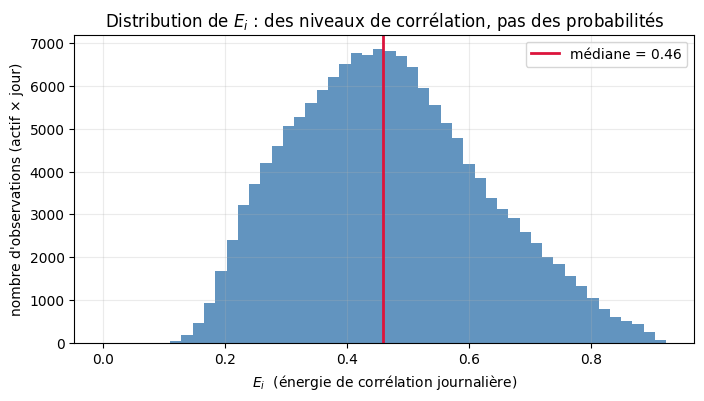

In [2]:
Ev = E[np.isfinite(E)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Ev, bins=50, color='steelblue', alpha=0.85)
ax.axvline(np.median(Ev), color='crimson', lw=2, label=f'médiane = {np.median(Ev):.2f}')
ax.set_xlabel(r'$E_i$  (énergie de corrélation journalière)')
ax.set_ylabel("nombre d'observations (actif × jour)")
ax.set_title(r"Distribution de $E_i$ : des niveaux de corrélation, pas des probabilités")
ax.legend(); ax.grid(alpha=0.25)
plt.show()

## 2. Un événement indépendant : le rendement extrême $I_i$

Pour chaque actif, on marque ses journées les plus violentes :
$$I_i(t) = \mathbf{1}\big(|r_i(t)| > q_i^{90}\big),$$
où $q_i^{90}$ est le 90ᵉ centile de $|r_i|$ **propre à l'actif** (donc ~10 % de
journées « extrêmes » par actif). Rien à voir avec les corrélations : c'est
purement l'amplitude du rendement.

Ci-dessous, un actif en exemple : ses journées extrêmes (points rouges) se
concentrent dans les périodes de tension.

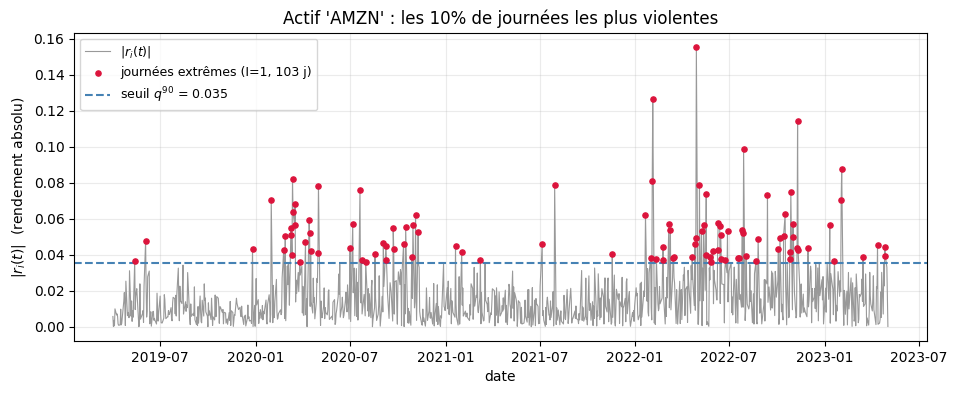

In [3]:
gi = ctx.asset_names.index('AMZN') if 'AMZN' in ctx.asset_names else 0
name = ctx.asset_names[gi]
absr = np.abs(R[gi])
thr  = np.nanquantile(absr, 0.90)              # seuil q90 de cet actif
ex   = absr > thr                              # journées extrêmes (I=1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(days, absr, color='0.6', lw=0.8, label=r'$|r_i(t)|$')
ax.scatter(days[ex], absr[ex], s=14, color='crimson', zorder=3,
           label=f'journées extrêmes (I=1, {ex.sum()} j)')
ax.axhline(thr, color='steelblue', lw=1.5, ls='--', label=f'seuil $q^{{90}}$ = {thr:.3f}')
ax.set_xlabel('date'); ax.set_ylabel(r'$|r_i(t)|$  (rendement absolu)')
ax.set_title(f"Actif '{name}' : les 10% de journées les plus violentes")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.show()

## 3. La calibration : $P(I=1 \mid E)$

On rassemble toutes les paires $(E_i(t), I_i(t))$ sur tous les actifs et tous les
jours. Puis, pour chaque tranche de $E$ (bin), on calcule la **fraction** de
journées extrêmes :
$$\xi_{emp}(E\text{-bin}) = \frac{\#\{I=1 \text{ dans le bin}\}}{\#\{\text{obs dans le bin}\}}.$$

Si $E$ élevé annonce vraiment plus de stress, cette courbe doit **monter**.

150526 paires (E, I) ; P(I=1) moyen = 0.100
xi_emp dépasse la moyenne (0.10) à partir de E* = 0.51


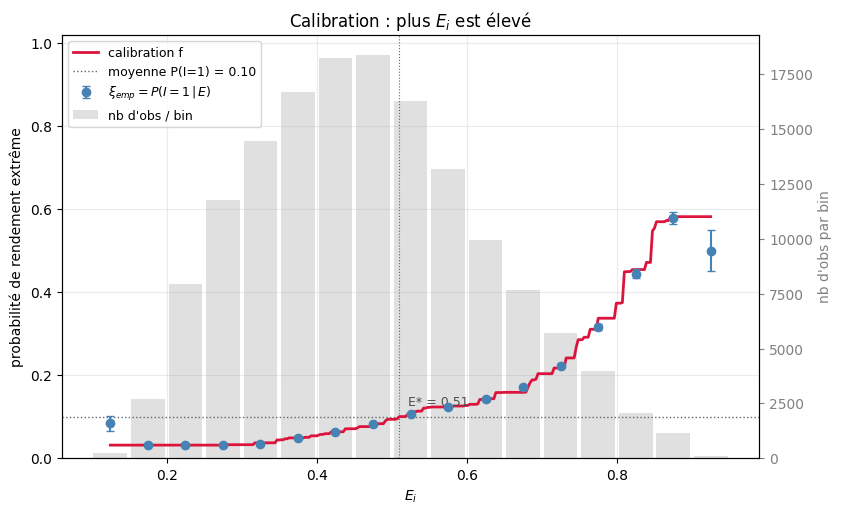

In [4]:
mp  = analysis.build_mapping(ctx, q=0.90, kind='monotone')
cur = mp.curve
grid = np.linspace(cur['centers'].min(), cur['centers'].max(), 300)
E_star = analysis.crossing(grid, mp.monotone(grid), mp.marginal)
print(f"{mp.Ev.size} paires (E, I) ; P(I=1) moyen = {mp.marginal:.3f}")
print(f"xi_emp dépasse la moyenne ({mp.marginal:.2f}) à partir de E* = {E_star:.2f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
axb = ax.twinx()
axb.bar(cur['centers'], cur['n'], width=0.045, color='0.88', zorder=0, label='nb d\'obs / bin')
axb.set_ylabel("nb d'obs par bin", color='0.5'); axb.tick_params(axis='y', colors='0.5')
axb.set_zorder(0); ax.set_zorder(1); ax.patch.set_visible(False)

ax.errorbar(cur['centers'], cur['p'], yerr=cur['se'], fmt='o', ms=6, color='steelblue',
            ecolor='steelblue', capsize=3, zorder=4, label=r'$\xi_{emp}=P(I=1\,|\,E)$')
ax.plot(grid, mp.monotone(grid), color='crimson', lw=2, zorder=3, label='calibration f')
ax.axhline(mp.marginal, color='0.4', lw=1, ls=':', zorder=2,
           label=f'moyenne P(I=1) = {mp.marginal:.2f}')
if E_star is not None:
    ax.axvline(E_star, color='0.4', lw=0.8, ls=':', zorder=2)
    ax.annotate(f'E* = {E_star:.2f}', (E_star, mp.marginal), textcoords='offset points',
                xytext=(6, 8), fontsize=9, color='0.3')
ax.set_xlabel(r'$E_i$'); ax.set_ylabel('probabilité de rendement extrême')
ax.set_title(r'Calibration : plus $E_i$ est élevé')
ax.set_ylim(0, max(1.0, cur['p'].max() + cur['se'].max()) * 1.02); ax.grid(alpha=0.25)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)
plt.show()

La courbe **monte** (de ~3 % à ~58 %) : $E_i$ prédit bien le rendement extrême.
Elle croise la moyenne (10 %) vers $E^*\approx0.5$ — au-delà, un actif est plus
stressé que la moyenne.

## 4. La fonction de conversion $f : E \mapsto$ probabilité

La courbe ci-dessus **est** la fonction $f$ qui convertit n'importe quel $E$ en
probabilité. Deux versions : une **collée aux données** et une **lisse**. C'est elle qu'on applique ensuite à $E_i(t)$ pour obtenir
$\xi_{emp}(t)=f(E_i(t))$.

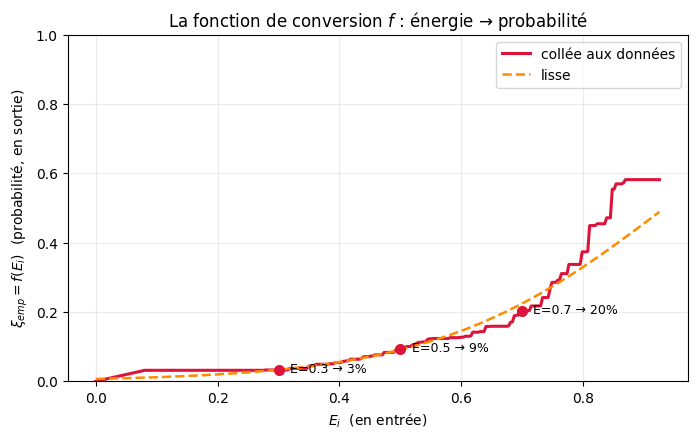

In [5]:
Eg = np.linspace(0, cur['centers'].max(), 300)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(Eg, mp.monotone(Eg), color='crimson', lw=2.2, label='collée aux données')
ax.plot(Eg, mp.smooth(Eg), color='darkorange', lw=1.8, ls='--', label='lisse')
for e in (0.3, 0.5, 0.7):
    y = float(mp.monotone([e])[0])
    ax.plot(e, y, 'o', color='crimson', ms=7)
    ax.annotate(f'E={e} → {y:.0%}', (e, y), textcoords='offset points',
                xytext=(8, -2), fontsize=9)
ax.set_xlabel(r'$E_i$  (en entrée)')
ax.set_ylabel(r'$\xi_{emp}=f(E_i)$  (probabilité, en sortie)')
ax.set_title(r'La fonction de conversion $f$ : énergie → probabilité')
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.25)
plt.show()

## 5. Comparaison dynamique — médiane sur les actifs, plusieurs crises

Au lieu d'un seul actif, on **agrège**. Pour chaque crise et **chaque actif en
crise** on calcule sa trajectoire SIS (initialisée sur $\xi_{emp}(0)$) et sa
probabilité empirique $\xi_{emp}(t)=f(E_i(t))$, puis on trace la **médiane sur
les actifs** (bande = quartiles 25–75 %). On le fait sur les 6 crises les mieux
peuplées : est-ce que $x^{SIS}$ (rouge) et $\xi_{emp}$ (bleu) se suivent ?

[cache] OK  crisis_map


6 crises (>=10 actifs) ; actifs par crise : 94, 92, 82, 78, 74, 73


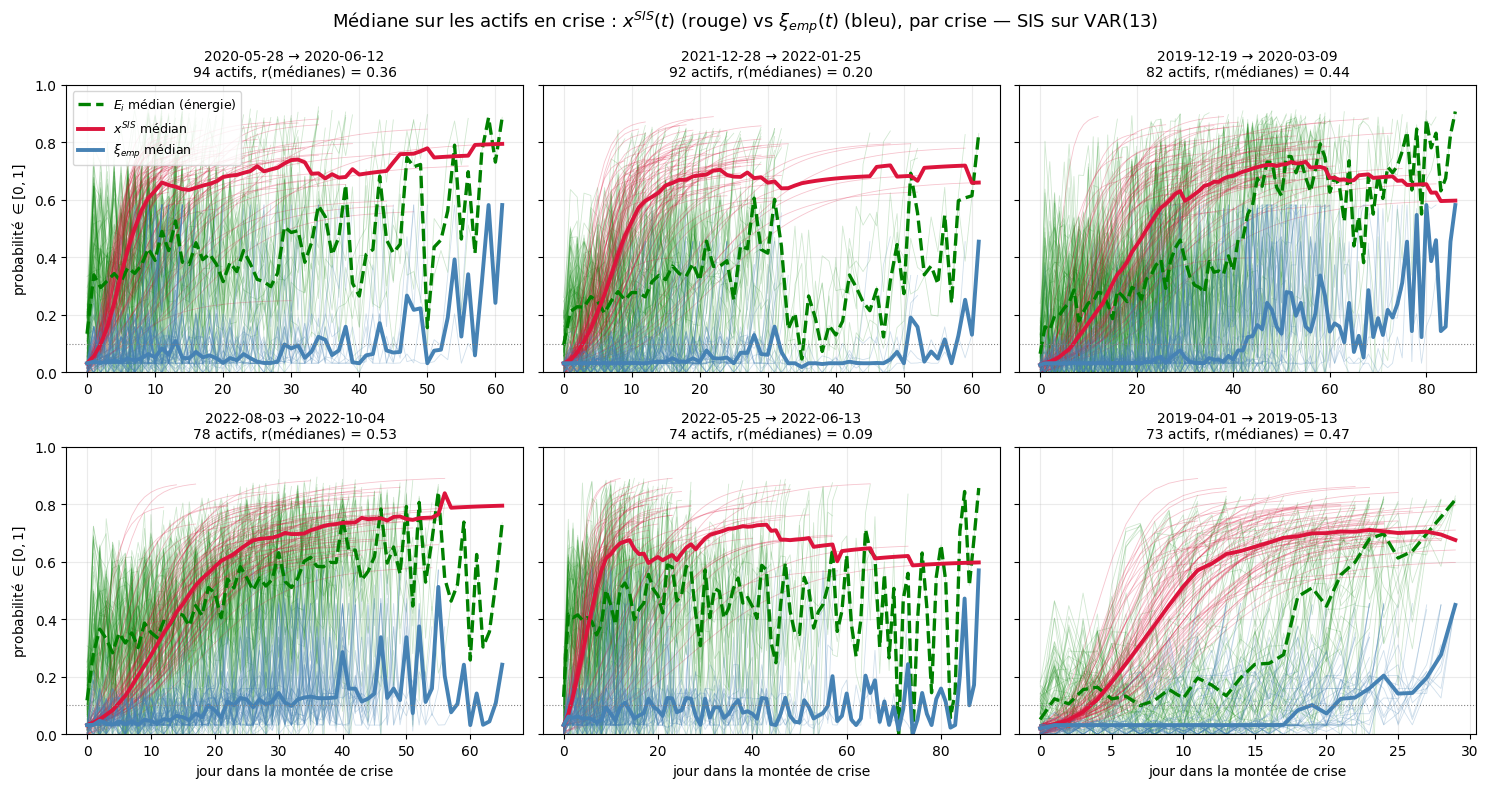

In [6]:
def _med(curves):
    """médiane + quartiles 25/75 sur des courbes de longueurs différentes (padding NaN)."""
    L = max((len(c) for c in curves), default=0)
    M = np.full((len(curves), L), np.nan)
    for r, c in enumerate(curves):
        M[r, :len(c)] = c
    return np.nanmedian(M, 0), np.nanpercentile(M, 25, 0), np.nanpercentile(M, 75, 0)

P  = analysis.load_periods(ctx)
fc = model.make_fit_context(ctx, P['crisis_map'])
A  = ctx.A_sis['VAR(13)']

per_data = []
for (pa, pb) in P['intervals_chrono']:
    cache = model.cache_signed(pa, pb, fc)
    if len(cache) < 10:                                  # crises trop peu peuplées ignorées
        continue
    XS, XE, XG = [], [], []
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 5:
            continue
        xe = analysis.map_energy(E_i, mp.f)                    # xi_emp(t) = f(E_i(t))
        d2 = dict(d, x0=analysis.map_energy(d['x0'], mp.f))    # SIS initialisé sur xi_emp(0)
        XS.append(model.integrate_fast(d2, gi, A)); XE.append(xe); XG.append(E_i)
    if len(XS) >= 10:
        per_data.append((pa, pb, XS, XE, XG))

per_data.sort(key=lambda t: -len(t[2]))                  # les mieux peuplées d'abord
per_data = per_data[:6]
print(f"{len(per_data)} crises (>=10 actifs) ; actifs par crise : "
      + ', '.join(str(len(d[2])) for d in per_data))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, (pa, pb, XS, XE, XG) in zip(axes.ravel(), per_data):
    mS, _, _ = _med(XS); mE, _, _ = _med(XE); mG, _, _ = _med(XG)
    for xg in XG:                                             # spaghetti : E_i brut (vert)
        ax.plot(np.arange(len(xg)), xg, color='green', alpha=0.18, lw=0.6)
    for xs in XS:                                             # x_SIS (rouge)
        ax.plot(np.arange(len(xs)), xs, color='crimson', alpha=0.25, lw=0.6)
    for xe in XE:                                             # xi_emp (bleu)
        ax.plot(np.arange(len(xe)), xe, color='steelblue', alpha=0.25, lw=0.6)
    ax.plot(np.arange(len(mG)), mG, color='green', lw=2.4, ls='--', label=r'$E_i$ médian (énergie)')
    ax.plot(np.arange(len(mS)), mS, color='crimson', lw=2.8, label=r'$x^{SIS}$ médian')
    ax.plot(np.arange(len(mE)), mE, color='steelblue', lw=2.8, label=r'$\xi_{emp}$ médian')
    ax.axhline(mp.marginal, color='0.5', lw=0.8, ls=':')
    L = min(len(mS), len(mE)); u = ~np.isnan(mS[:L]) & ~np.isnan(mE[:L])
    r = pearsonr(mS[:L][u], mE[:L][u])[0] if u.sum() > 2 else float('nan')
    ax.set_title(f"{ctx.all_days[pa]} → {ctx.all_days[pb]}\n{len(XS)} actifs, r(médianes) = {r:.2f}", fontsize=10)
    ax.set_ylim(0, 1); ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=9, loc='upper left')
for ax in axes[1, :]: ax.set_xlabel('jour dans la montée de crise')
for ax in axes[:, 0]: ax.set_ylabel(r'probabilité $\in[0,1]$')
fig.suptitle(r'Médiane sur les actifs en crise : $x^{SIS}(t)$ (rouge) vs $\xi_{emp}(t)$ (bleu), par crise — SIS sur VAR(13)', fontsize=13)
fig.tight_layout()
plt.show()

4 crises ; actifs bien ajustés (R²>0.6) par crise : 16, 5, 5, 5


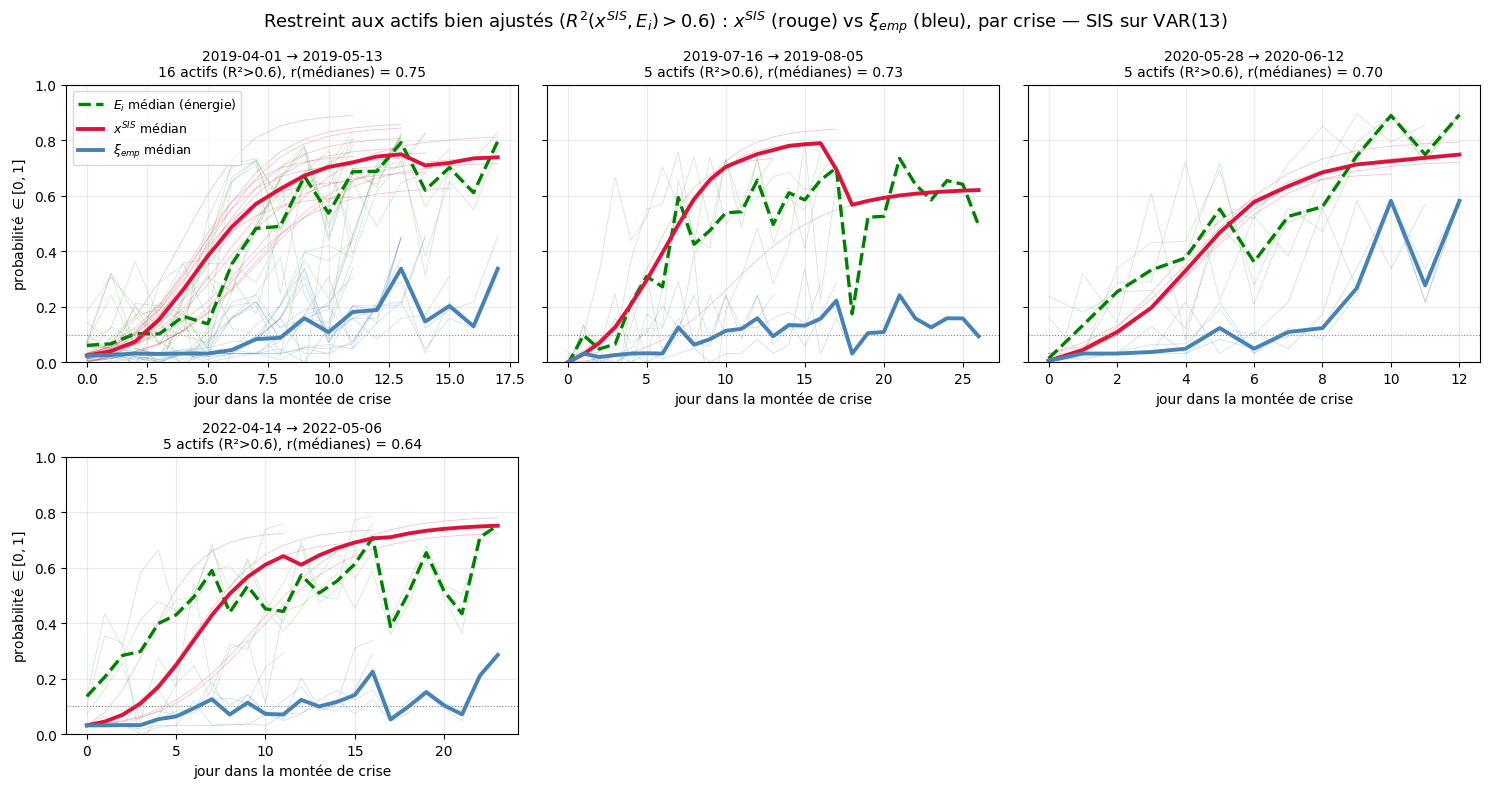

In [7]:
# ── Variante : on ne garde que les actifs BIEN AJUSTÉS (R²(x_SIS, E_i) > 0.6), comme le rapport ──
# (réutilise _med, P, fc, A, mp de la cellule précédente)
R2_MIN = 0.6
per_sel = []
for (pa, pb) in P['intervals_chrono']:
    cache = model.cache_signed(pa, pb, fc)
    XS, XE, XG = [], [], []
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 5:
            continue
        xt_E = model.integrate_fast(d, gi, A)                     # SIS init E_i -> sert à juger le fit
        if linregress(E_i[ok], xt_E[ok]).rvalue ** 2 <= R2_MIN:   # on écarte les mal ajustés
            continue
        xe = analysis.map_energy(E_i, mp.f)                       # xi_emp(t) = f(E_i(t))
        d2 = dict(d, x0=analysis.map_energy(d['x0'], mp.f))       # SIS initialisé sur xi_emp(0)
        XS.append(model.integrate_fast(d2, gi, A)); XE.append(xe); XG.append(E_i)
    if len(XS) >= 5:
        per_sel.append((pa, pb, XS, XE, XG))

per_sel.sort(key=lambda t: -len(t[2]))
per_sel = per_sel[:6]
print(f"{len(per_sel)} crises ; actifs bien ajustés (R²>{R2_MIN}) par crise : "
      + ', '.join(str(len(d[2])) for d in per_sel))

n = len(per_sel)
ncols = min(3, n); nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True, squeeze=False)
axes = axes.ravel()
for k, (pa, pb, XS, XE, XG) in enumerate(per_sel):
    ax = axes[k]
    mS, _, _ = _med(XS); mE, _, _ = _med(XE); mG, _, _ = _med(XG)
    for xg in XG:                                             # spaghetti : E_i brut (vert)
        ax.plot(np.arange(len(xg)), xg, color='green', alpha=0.18, lw=0.6)
    for xs in XS:                                             # x_SIS (rouge)
        ax.plot(np.arange(len(xs)), xs, color='crimson', alpha=0.25, lw=0.6)
    for xe in XE:                                             # xi_emp (bleu)
        ax.plot(np.arange(len(xe)), xe, color='steelblue', alpha=0.25, lw=0.6)
    ax.plot(np.arange(len(mG)), mG, color='green', lw=2.4, ls='--', label=r'$E_i$ médian (énergie)')
    ax.plot(np.arange(len(mS)), mS, color='crimson', lw=2.8, label=r'$x^{SIS}$ médian')
    ax.plot(np.arange(len(mE)), mE, color='steelblue', lw=2.8, label=r'$\xi_{emp}$ médian')
    ax.axhline(mp.marginal, color='0.5', lw=0.8, ls=':')
    L = min(len(mS), len(mE)); u = ~np.isnan(mS[:L]) & ~np.isnan(mE[:L])
    r = pearsonr(mS[:L][u], mE[:L][u])[0] if u.sum() > 2 else float('nan')
    ax.set_title(f"{ctx.all_days[pa]} → {ctx.all_days[pb]}\n{len(XS)} actifs (R²>{R2_MIN}), r(médianes) = {r:.2f}", fontsize=10)
    ax.set_ylim(0, 1); ax.grid(alpha=0.25); ax.set_xlabel('jour dans la montée de crise')
for k in range(0, n, ncols):
    axes[k].set_ylabel(r'probabilité $\in[0,1]$')
for ax in axes[n:]:
    ax.axis('off')
axes[0].legend(fontsize=9, loc='upper left')
fig.suptitle(r'Restreint aux actifs bien ajustés ($R^2(x^{SIS},E_i)>0.6$) : $x^{SIS}$ (rouge) vs $\xi_{emp}$ (bleu), par crise — SIS sur VAR(13)', fontsize=13)
fig.tight_layout()
plt.show()

## 6. Même sélection que le rapport (`fig_3_sis_trajectoires`), par réseau

On reprend **exactement la sélection de la figure du rapport** : montées de crise détectées sur les pics de $\langle|C|\rangle$, courbes bien ajustées ($R^2>$ seuil), **un panneau par réseau de contagion**. On superpose la nouvelle probabilité $\xi_{emp}=P(I{=}1\mid E)$ (bleu) à $E_i$ (vert) et $x^{SIS}$ (rouge).

[cache] OK  peak_period_data


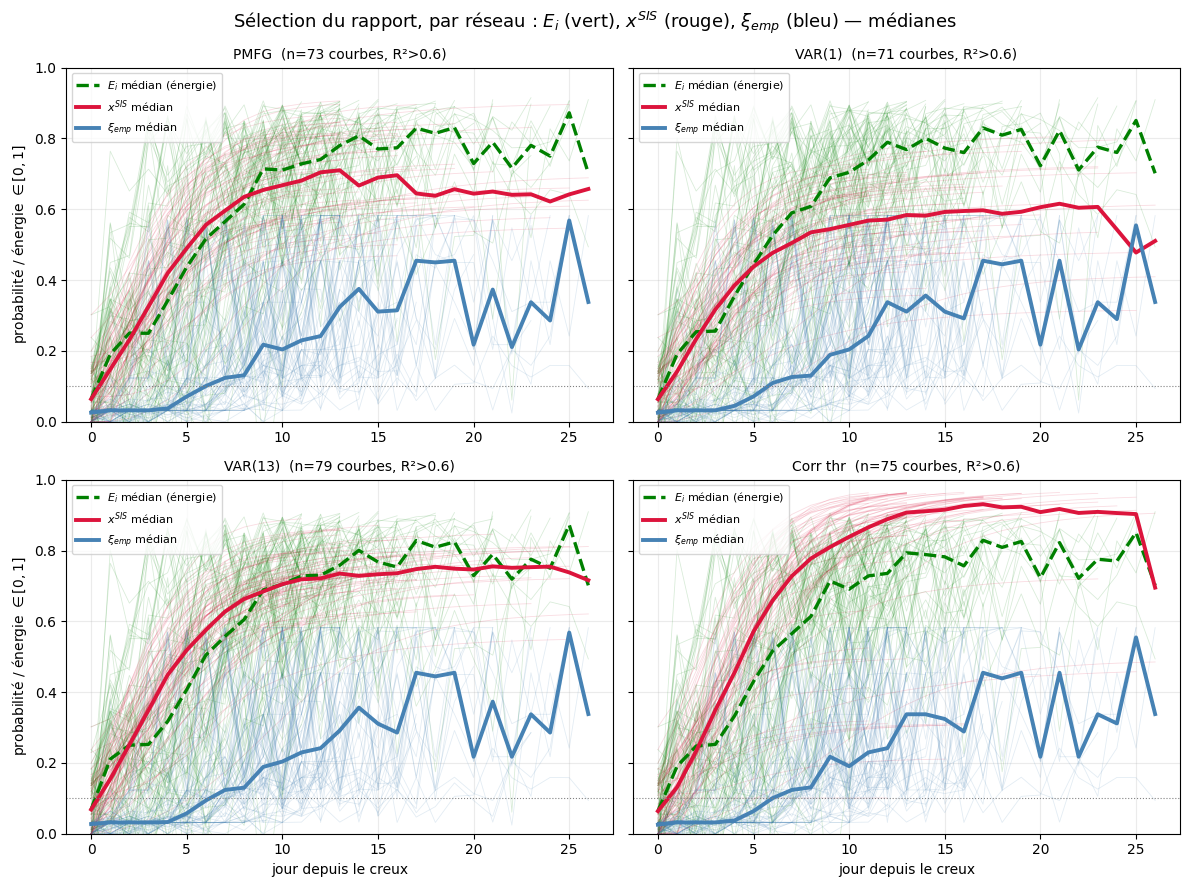

In [8]:
# Sélection identique à fig_3_sis_trajectoires (rapport) : par réseau, courbes R²>seuil.
PK   = analysis.fit_peaks(ctx, P['crisis_map'])
coll = analysis.collect_by_method(PK['peak_pd'], PK['peak_rises'])

def _median(curves):
    L = max((len(c) for c in curves), default=0)
    M = np.full((len(curves), L), np.nan)
    for r, c in enumerate(curves):
        M[r, :len(c)] = c
    return np.nanmedian(M, 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for ax, m in zip(axes.ravel(), config.SIS_MODELS):
    c  = coll[m]
    XE = [analysis.map_energy(E_i, mp.f) for E_i in c['Es']]      # xi_emp par courbe
    for E_i, xs, xe in zip(c['Es'], c['Xs'], XE):
        ok = ~np.isnan(E_i)
        ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='green',     alpha=0.15, lw=0.6)
        ax.plot(np.arange(len(xs)),      xs,      color='crimson',   alpha=0.15, lw=0.6)
        ax.plot(np.arange(len(xe))[ok],  xe[ok],  color='steelblue', alpha=0.15, lw=0.6)
    mG, mS, mE = _median(c['Es']), _median(c['Xs']), _median(XE)
    if len(mG):
        ax.plot(np.arange(len(mG)), mG, color='green',     lw=2.4, ls='--', label=r'$E_i$ médian (énergie)')
        ax.plot(np.arange(len(mS)), mS, color='crimson',   lw=2.8,          label=r'$x^{SIS}$ médian')
        ax.plot(np.arange(len(mE)), mE, color='steelblue', lw=2.8,          label=r'$\xi_{emp}$ médian')
        ax.legend(fontsize=8, loc='upper left')
    ax.axhline(mp.marginal, color='0.5', lw=0.8, ls=':')          # niveau marginal P(I=1)
    ax.set_ylim(0, 1); ax.grid(alpha=0.25)
    ax.set_title(f'{m}  (n={len(c["r2s"])} courbes, R²>{config.R2_SEUIL})', fontsize=10)
for ax in axes[1, :]: ax.set_xlabel('jour depuis le creux')
for ax in axes[:, 0]: ax.set_ylabel(r'probabilité / énergie $\in[0,1]$')
fig.suptitle(r'Sélection du rapport, par réseau : $E_i$ (vert), $x^{SIS}$ (rouge), $\xi_{emp}$ (bleu) — médianes', fontsize=13)
fig.tight_layout()
plt.show()

## En résumé

1. $E_i$ = énergie de corrélation, sur $[0,1]$ mais **pas** une probabilité.
2. $I_i$ = journée à rendement extrême (top 10 % par actif), critère **indépendant**.
3. La fraction de journées extrêmes par tranche de $E$ donne une **vraie
   probabilité** $\xi_{emp}=P(I=1\,|\,E)$, croissante.
4. La fonction $f$ convertit $E_i(t)$ en $\xi_{emp}(t)$.
5. On compare alors $x_i^{SIS}(t)$ et $\xi_{emp}(t)$ — **deux probabilités** — sur
   le même graphe.

Comme $f$ est croissante, l'ordre des actifs ne change pas : $\xi_{emp}$ rend la
comparaison légitime en **unités**, sans modifier le classement.